In [19]:
from importlib import reload
import os
import sys
# Set up paths for utility imports
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')

os.chdir(current_dir)
# Ensure the utilities directory is in the import path
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
    
import plotting
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from kan import KAN


In [25]:
 

# =====================================================
# Reproducibility
# =====================================================
torch.manual_seed(1)
np.random.seed(1)

# =====================================================
# Target function
# =====================================================
def f(x):
    return x**3 + x**2 - x - 1

# =====================================================
# Training data
# =====================================================
n_train = 60

x_train = np.linspace(-3, 3, n_train)
y_train = f(x_train)

x_test = np.linspace(-3, 3, 500)
y_exact = f(x_test)

X_train = torch.tensor(x_train[:, None], dtype=torch.float32)
Y_train = torch.tensor(y_train[:, None], dtype=torch.float32)

X_test = torch.tensor(x_test[:, None], dtype=torch.float32)

# =====================================================
# KAN model
# =====================================================
model = KAN(
    width=[1,4,4,1],
    grid=3,
    k=1,
    seed=1
)

# =====================================================
# Train
# =====================================================

dataset = {
    'train_input': X_train,
    'train_label': Y_train,
    'test_input': X_train,
    'test_label': Y_train,
}

model.fit(
    dataset,
    opt="LBFGS",
    steps=100,
    lamb=0.0,
)

# =====================================================
# Prediction
# =====================================================
model.eval()

with torch.no_grad():

    y_pred = model(X_test)

    if isinstance(y_pred, tuple):
        y_pred = y_pred[0]

    y_pred = y_pred.detach().cpu().numpy().flatten()

# =====================================================
# Relative error
# =====================================================
rel_error = np.linalg.norm(y_pred-y_exact)/np.linalg.norm(y_exact)

print(f"Relative L2 error = {rel_error:.3e}")

# =====================================================
# Compute hidden activations
# =====================================================
with torch.no_grad():

    _ = model(X_test)

    a1 = model.acts[1]
    a2 = model.acts[2]

    if isinstance(a1, torch.Tensor):
        a1 = a1.detach().cpu().numpy()

    if isinstance(a2, torch.Tensor):
        a2 = a2.detach().cpu().numpy()



checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                          | 0/100 [00:00<?, ?it/s]

| train_loss: 2.94e-02 | test_loss: 2.94e-02 | reg: 3.68e+01 | : 100%|█| 100/100 [00:05<00:00, 17.88

saving model version 0.1
Relative L2 error = 6.332e-03


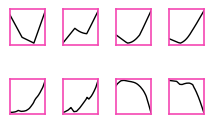

In [26]:
# =====================================================
# Plot
# =====================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(2.5,1.5),
    sharex=True
)

# First hidden layer
for i in range(4):

    ax = axes[0,i]

    ax.plot(
        x_test,
        a1[:,i],
        color='black',
        lw=1
    )

# Second hidden layer
for i in range(4):

    ax = axes[1,i]

    ax.plot(
        x_test,
        a2[:,i],
        color='black',
        lw=1
    )

# =====================================================
# Formatting
# =====================================================

for ax in axes.ravel():

    ax.set_xlim(-3,3)

    ax.set_box_aspect(1)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color("#f547b3ff")
        spine.set_linewidth(1.2)

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

plt.savefig(
    "figures/kan.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Relative L2 error = 6.332e-03


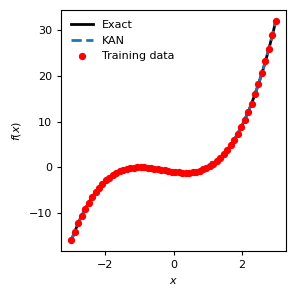

In [27]:
# =====================================================
# Prediction
# =====================================================
model.eval()

with torch.no_grad():

    y_pred = model(X_test)

    # Some pykan versions return (prediction, ...)
    if isinstance(y_pred, tuple):
        y_pred = y_pred[0]

    y_pred = y_pred.detach().cpu().numpy().flatten()

# =====================================================
# Relative L2 error
# =====================================================
rel_error = np.linalg.norm(y_pred - y_exact) / np.linalg.norm(y_exact)

print(f"Relative L2 error = {rel_error:.3e}")

# =====================================================
# Plot approximation
# =====================================================

plt.figure(figsize=(3,3))

# Exact solution
plt.plot(
    x_test,
    y_exact,
    color='black',
    lw=2,
    label='Exact'
)

# KAN prediction
plt.plot(
    x_test,
    y_pred,
    '--',
    color='tab:blue',
    lw=2,
    label='KAN'
)

# Training points
plt.scatter(
    x_train,
    y_train,
    s=18,
    color='red',
    zorder=5,
    label='Training data'
)

plt.xlabel(r"$x$")
plt.ylabel(r"$f(x)$")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "figures/kan_approximation.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()